# VOC2007：两张单图演示 → 框监督批量学习

固定 CNN → 三层 Gmem/Gpos，使用本地 VOC2007 XML。先执行两张独立原图上的单目标演示，观察同类组合能否被复用；之后开启批量建图。**单图学习后的原图检索属于自检，不是泛化成绩。**

本 Notebook 只经过静态编译，没有预先运行训练。默认开启两张单图演示，批量训练/留出查询/分类头/检测分别显式开启；所有相似度及分割阈值保持代码默认值。


本轮修正：默认 grad_refined 与完整 VOC2007 路径；重启内核从头执行。旧运行输出保存于 results/supervised_graph/notebook_before_recall_correction_20260921.ipynb。先查看两图普通检索与已知写入原点诊断；批量学习默认关闭，由用户确认结果后开启。


In [ ]:
import sys, json, copy, random, time, gc, hashlib
from dataclasses import asdict
from pathlib import Path
from collections import Counter
from datetime import datetime
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display
root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/nns').is_dir())
if str(root / 'src') not in sys.path:
    sys.path.insert(0, str(root / 'src'))
from nns.memorygraphs.graph_memorypool_onceoptimizer import MemoryConfig, MultilevelCoordinator, SearchBudget, OnceGraphBuilder, GmemoryI, GmemoryII, advanced_partition_contract
from nns.memorygraphs.supervised_data import AnnotationDataset, SupervisedConfig, ObjectViewTransform
from nns.memorygraphs.supervised_graph_learning import SupervisedGraphOptimizer
from nns.memorygraphs.supervised_readout import FixedCNNEncoder, ClassEvidenceReadout, ClassifierTrainer, ProposalDetector, detection_metrics
from nns.memorygraphs.supervised_experiment import SupervisedExperiment, resource_snapshot
VOC_ROOT = Path('/home/p/code/datasets/VOC2007/VOCdevkit/VOC2007')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASSES = ('cat', 'dog', 'car')
EXCLUDE_DIFFICULT = True  # 自定义已知框分类协议；不是 VOC 官方 difficult-aware 检测评价
PARTITION_MODE = 'grad_refined'  # grad_refined / grad_gated / independent / legacy_grad_partition
GRAD_CONTINUITY_THRESHOLD = None  # 默认跟随 tau_grad_coh；仅调整此参数不改变三个模态自身阈值
RUN_PARTITION_COMPARISON = False  # 同一 CNN 输出上比较三种算法；不写入长期图
RUN_PARTITION_COMPARISON = True 
PROFILE_STAGES = True  # CUDA 同步分段计时有额外开销，长期运行可关闭
BATCH_START_IMAGE = 0
RUN_SINGLE_DEMOS = True
RUN_WRITE_RECALL_AUDIT = True  # 已知原点仅作诊断，不计作普通检索成功
RUN_MEMORY_BUILD = True  # 先检查两图检索闭环，再手动开启批量
RUN_QUERY = False
RUN_HEAD_FIT = False
RUN_DETECTION = False
BATCH_IMAGE_LIMIT = 20   # 原图数，不是目标数；None 使用全部 memory_build
QUERY_IMAGE_LIMIT = 20   # None 查询整个对应留出集；小样本可能缺类
CHECKPOINT_EVERY = 10   # 每多少个标注目标保存一次，0 只在结束/中断时保存
RESUME_CHECKPOINT = None  # 可填写已有 memory.pt；必须使用完全相同的划分和配置
config = SupervisedConfig()
search_budget = SearchBudget(max_seconds=None, max_template_pairs=None)
OUTPUT = root / 'results/supervised_graph' / datetime.now().strftime('voc2007_%Y%m%d_%H%M%S_%f')
MODALITIES = {0: 'grad', 1: 'RGB', 2: 'curv', 3: 'aps (anisotropy)', 4: 'ori'}
def sync():
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize(DEVICE)
print({'device': str(DEVICE), 'torch': torch.__version__, 'voc_root': str(VOC_ROOT), 'output': str(OUTPUT)})


{'device': 'cuda', 'torch': '2.10.0+cu128', 'voc_root': '/home/p/code/datasets/VOC2007/VOCdevkit/VOC2007', 'output': '/home/p/code/Conscious-linux/Conscious-demo/results/supervised_graph/voc2007_20260921_221651_827965'}


## 1. 官方划分与样本检查

官方 train 只用于 memory_build/readout_fit，官方 val 保留为 validation。test 未解压时保持空集，不拿 val 冒充 test；以后解压 test 后重新执行本节即可识别。所有集合按原图去重。

本演示默认过滤 difficult 目标，保留同图中其他可用目标。这是框分类调试协议；检测 AP 目前仍是简化指标。更改类别时会检查各非空划分的类别覆盖。


In [2]:
class DemoVOCDataset(AnnotationDataset):
    def annotations(self, image_id):
        annotations = super().annotations(image_id)
        return [a for a in annotations if not EXCLUDE_DIFFICULT or a.flags.get('difficult') != '1']

dataset = DemoVOCDataset(VOC_ROOT / 'JPEGImages', VOC_ROOT / 'Annotations',
    coordinate_convention='1based_inclusive', dataset_version='VOC2007')
raw_dataset = AnnotationDataset(VOC_ROOT / 'JPEGImages', VOC_ROOT / 'Annotations',
    coordinate_convention='1based_inclusive', dataset_version='VOC2007')
manifest = dataset.manifest()
classes = tuple(CLASSES)
def official_ids(name, required=True):
    p = VOC_ROOT / 'ImageSets/Main' / f'{name}.txt'
    if not p.exists():
        if required:
            raise FileNotFoundError(p)
        return []
    ids = p.read_text().split()
    missing = [k for k in ids if k not in manifest or not (VOC_ROOT / 'JPEGImages' / f'{k}.jpg').exists()]
    if missing:
        raise RuntimeError(f'{name} 缺少图片/标注: {missing[:10]}')
    return ids
official = {'train': official_ids('train'), 'validation': official_ids('val'), 'test': official_ids('test', False)}
if any(set(official[a]) & set(official[b]) for a,b in (('train','validation'),('train','test'),('validation','test'))):
    raise RuntimeError('官方划分存在原图交叉')
def eligible(ids):
    return [k for k in ids if any(a.class_id in classes for a in manifest[k])]
train_ids = sorted(eligible(official['train']))
random.Random(config.seed).shuffle(train_ids)
cut = round(.75 * len(train_ids))
split_manifest = {'seed': config.seed, 'classes': list(classes), 'dataset': 'VOC2007',
    'exclude_difficult': EXCLUDE_DIFFICULT, 'protocol': 'official_train_internal_75_25_official_val_test',
    'splits': {'memory_build': train_ids[:cut], 'readout_fit': train_ids[cut:],
               'validation': eligible(official['validation']), 'test': eligible(official['test'])}}
summary = []
for split, ids in split_manifest['splits'].items():
    counts = Counter(a.class_id for k in ids for a in manifest[k] if a.class_id in classes)
    if ids and set(classes) - set(counts):
        raise ValueError(f'{split} 类别覆盖不足: {set(classes)-set(counts)}')
    summary.append({'split': split, 'images': len(ids), 'objects': sum(counts.values()), **dict(counts)})
display(pd.DataFrame(summary).fillna(0))
if not split_manifest['splits']['test']:
    print('当前 VOC_ROOT 下没有 test 划分；请核对数据目录，test 评价会跳过。')


,split,images,objects,dog,car,cat
0,memory_build,549,806,183,488,135
1,readout_fit,183,258,70,137,51
2,validation,723,1072,257,625,190
3,test,1441,2048,489,1201,358


## 2. 从建图集合选两张不同原图

优先取同一类别，以观察第二张图是否复用第一张图的实体；每图取该类别面积最大的非 difficult 目标。选择依据只有标注和面积，不依赖模型成绩。不足两张时明确报错。展示图中红框是当前目标，灰框是同图其他标注目标。


{'image_id': '007530', 'bbox': (182.0, 60.0, 326.0, 167.0), 'round_trip': (182.0, 60.0, 326.0, 167.0)}
{'image_id': '000209', 'bbox': (13.0, 75.0, 400.0, 375.0), 'round_trip': (13.0, 75.00000000000001, 400.0, 375.0)}


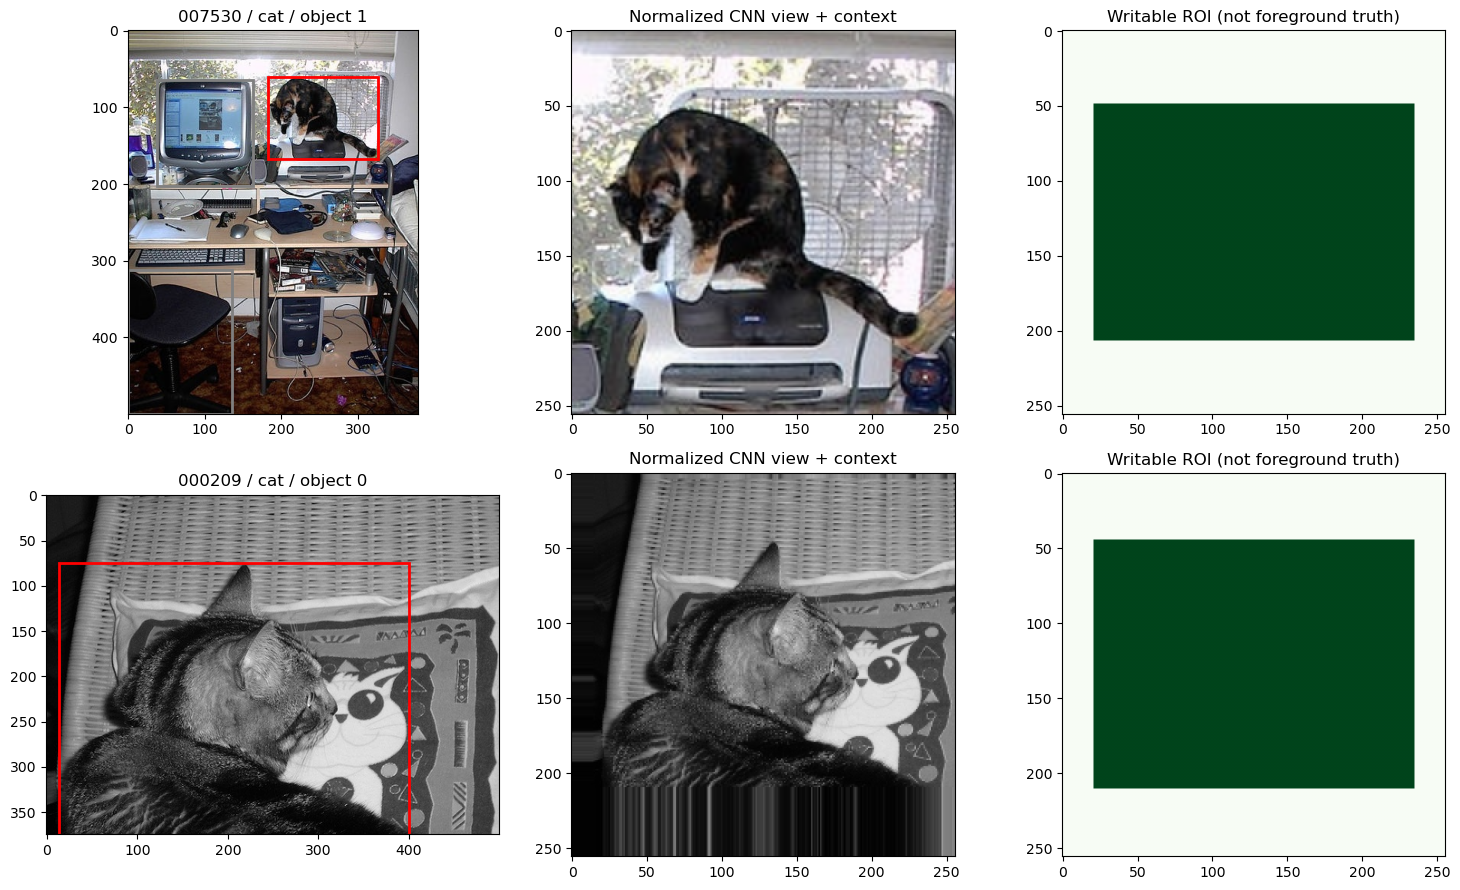

In [3]:
demo_annotations = []
for label in classes:
    candidates = []
    for image_id in split_manifest['splits']['memory_build']:
        objects = [a for a in manifest[image_id] if a.class_id == label]
        if objects:
            candidates.append(max(objects, key=lambda a: (a.bbox[2]-a.bbox[0])*(a.bbox[3]-a.bbox[1])))
    if len(candidates) >= 2:
        demo_annotations = candidates[:2]
        break
if len(demo_annotations) != 2:
    raise RuntimeError('memory_build 中没有可用于同类两图演示的类别')
transform = ObjectViewTransform(config)
def load_observation(annotation):
    image, _ = dataset.load_image_objects(annotation.image_id)
    # 即使 difficult 不参与学习，其框仍用于单图演示的归属不确定性标记。
    others = raw_dataset.annotations(annotation.image_id)
    observation = transform.make_view(image, annotation,
        other_boxes=[a.bbox for a in others if a.object_id != annotation.object_id])
    return image, observation, others

demo_inputs = []
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i, annotation in enumerate(demo_annotations):
    image, observation, others = load_observation(annotation)
    demo_inputs.append((annotation, observation))
    axes[i,0].imshow(image[0].permute(1,2,0))
    for a in others:
        x0,y0,x1,y1 = a.bbox
        axes[i,0].add_patch(Rectangle((x0,y0),x1-x0,y1-y0,fill=False,
            edgecolor='red' if a.object_id == annotation.object_id else 'gray',linewidth=2))
    axes[i,0].set_title(f'{annotation.image_id} / {annotation.class_id} / object {annotation.object_id}')
    axes[i,1].imshow(observation.view_tensor[0].permute(1,2,0))
    axes[i,1].set_title('Normalized CNN view + context')
    axes[i,2].imshow(observation.valid_mask.cpu(),cmap='Greens',vmin=0,vmax=1)
    axes[i,2].set_title('Writable ROI (not foreground truth)')
    print({'image_id': annotation.image_id, 'bbox': annotation.bbox,
           'round_trip': observation.box_to_original(observation.canonical_box)})
plt.tight_layout()
plt.show()


## 3. 初始化与调试工具

两图共用一份演示记忆，但批量实验稍后新建自己的记忆，避免示例重放影响统计。调试快照复用实际建图报告，不额外重跑区域分割；仅保存当前观察，释放后不占用批量训练内存。

区域图的黑色是无效/未分区位置，★ 表示选入实体的区域锚点，当前 grad_gated 模式只显示独立区域 ID；仅旧算法对照中的 `r←p` 表示复制的 grad 父区域。不同模态颜色编号独立，不能用同色判断跨模态对应。


In [4]:
def gate_audit(report, cfg):
    rows=[]
    for mid in (2,3,4):
        support=report.supports.get(mid)
        if support is None: continue
        allowed=support.gate_context.get('grad_eligible')
        regions=[r for r in report.regions if r.modality_id==mid]
        sampled=[p for r in regions for p in r.samples]
        independent=advanced_partition_contract(cfg)['mode']=='grad_gated'
        row={'modality':MODALITIES[mid],'own_gate_pixels':int(support.gate_context.get('own_gate_before_grad',support.writable).sum()),
             'grad_eligible':int(allowed.sum()) if allowed is not None else None,
             'writable':int(support.writable.sum()),'active':int(support.support.sum()),
             'regions':len(regions),'samples':len(sampled),
             'inherited_regions':sum(r.parent_region_id is not None for r in regions)}
        if independent:
            outside=~allowed.astype(bool)
            row['gate_violations']=int((support.writable & outside).sum())+sum(bool(outside.flat[p]) for p in sampled)
            assert row['gate_violations']==0, '门控外存在可写/采样点'
            assert all(not outside.flat[p] for r in regions for p in r.pixels), '区域跨出 grad 门控'
            assert row['inherited_regions']==0, '新模式不应复制 grad 分区'
        if advanced_partition_contract(cfg)['mode']=='grad_refined':
            row['parent_violations']=sum(int(np.count_nonzero(report.labels[0].flat[r.pixels] != r.support_parent_region_id)) for r in regions)
            assert row['parent_violations']==0, '属性越出所属 grad 父域'
        rows.append(row)
    return rows

def audit_memory(learner):
    model=learner.model
    broken=[(eid,role) for eid,e in model.gmem_iii.entity_nodes.items()
        for role,m in e.component_edges.items() if m['sem_id'] not in model.gmem_ii.semantic_nodes]
    nonfinite=[nid for nid,node in model.gmem_i.nodes.items() if not torch.isfinite(node.prototype).all()]
    bad_ledger=[k for k,v in learner.ledger.items() if v['entity_id'] not in model.gmem_iii.entity_nodes]
    assert not broken and not nonfinite and not bad_ledger, (broken,nonfinite,bad_ledger)
    patterns=Counter(tuple(sorted({model.gmem_i.nodes[model.gmem_ii.semantic_nodes[m['sem_id']].anchor_id].modality_id
        for m in e.component_edges.values()})) for e in model.gmem_iii.entity_nodes.values())
    return {'broken_roles':len(broken),'nonfinite_prototypes':len(nonfinite),'bad_ledger':len(bad_ledger),
        'modality_patterns':dict(patterns),'visually_confirmed':sum((e.supervision or {}).get('visually_confirmed',False)
            for e in model.gmem_iii.entity_nodes.values())}

def new_system(partition_mode=PARTITION_MODE):
    cfg = MemoryConfig()
    for name in dir(cfg):
        value = getattr(cfg, name)
        if isinstance(value, (dict, list, set)):
            setattr(cfg, name, copy.deepcopy(value))
    cfg.once_bind_edge_attributes = partition_mode == 'legacy_grad_partition'
    cfg.once_advanced_partition_mode = 'independent' if cfg.once_bind_edge_attributes else partition_mode
    cfg.once_advanced_grad_continuity = GRAD_CONTINUITY_THRESHOLD
    cfg.device = DEVICE
    cfg.H = cfg.W = config.view_size
    encoder = FixedCNNEncoder(cfg, config)
    model = MultilevelCoordinator(cfg)
    learner = SupervisedGraphOptimizer(model, classes, config)
    assert advanced_partition_contract(cfg)['mode'] == partition_mode
    print('segmentation contract:', advanced_partition_contract(cfg))
    OUTPUT.mkdir(parents=True,exist_ok=True)
    sources=['src/nns/memorygraphs/'+name+'.py' for name in (
        'graph_memorypool_onceoptimizer','supervised_graph_learning','supervised_data','supervised_readout')]
    manifest={'torch':torch.__version__,'device':str(DEVICE),'voc_root':str(VOC_ROOT),
        'partition':advanced_partition_contract(cfg),'supervised_config':asdict(config),
        'source_sha256':{name:hashlib.sha256((root/name).read_bytes()).hexdigest() for name in sources}}
    (OUTPUT/'run_contract.json').write_text(json.dumps(manifest,ensure_ascii=False,indent=2))
    return cfg, encoder, model, learner

def graph_counts(model):
    return {'GmemI': len(model.gmem_i.nodes), 'GmemII': len(model.gmem_ii.semantic_nodes),
            'GmemIII': len(model.gmem_iii.entity_nodes)}

def entity_rows(model):
    return [{'entity': eid, 'label': (e.supervision or {}).get('label_id'), 'status': e.status,
             'members': len(e.component_edges), 'support': e.evidence.support,
             'annotation_confirmed': (e.supervision or {}).get('confirmation'),
             'visually_confirmed': (e.supervision or {}).get('visually_confirmed', False)}
            for eid,e in model.gmem_iii.entity_nodes.items()]

def show_regions(debug):
    if debug is None:
        print('本次没有构图快照（例如已处理的标注直接返回）。')
        return
    report = debug['report']
    selected = set(debug['selected_ids'])
    fig, axes = plt.subplots(1,5,figsize=(20,4))
    cmap = copy.copy(plt.get_cmap('tab20')); cmap.set_bad('black')
    for mid,ax in enumerate(axes):
        labels = report.labels.get(mid)
        if labels is None:
            ax.set_title(f'{MODALITIES[mid]}: missing'); ax.axis('off'); continue
        ax.imshow(np.ma.masked_where(labels < 0, labels),cmap=cmap,interpolation='nearest')
        for r in report.regions:
            if r.modality_id == mid and r.region_id in selected and r.anchor is not None:
                y,x = divmod(r.anchor, report.shape[1])
                ax.scatter(x,y,marker='*',s=65,c='white',edgecolors='black')
                parent = r.support_parent_region_id if r.support_parent_region_id is not None else r.parent_region_id
                text = str(r.region_id) + (f'←grad {parent}' if parent is not None else '')
                ax.text(x+2,y+2,text,fontsize=7,color='white',bbox=dict(facecolor='black',alpha=.5,pad=1))
        ax.set_title(f'{MODALITIES[mid]} / selected anchors'); ax.axis('off')
    plt.tight_layout(); plt.show()
    display(pd.DataFrame([{'region':r.region_id,'modality':MODALITIES[r.modality_id],
        'parent_grad':r.parent_region_id,'support_parent':r.support_parent_region_id,'completed':r.completed,'pixels':len(r.pixels),'samples':len(r.samples),
        'selected':r.region_id in selected,'truncated':r.budget_truncated,
        'reason':debug['selection']['rejected'].get(r.region_id, ', '.join(r.reasons))}
        for r in report.regions]))
    display(pd.DataFrame([{'region':rid, **values} for rid,values in debug['selection'].get('quality_components',{}).items() if rid in selected]))
    print('构图:', report.summary())
    display(pd.DataFrame(gate_audit(report, demo_cfg)))
    print('成员选择:', {k:v for k,v in debug['selection'].items() if k not in ('quality','quality_components')})

def show_entity(model, eid):
    if eid not in model.gmem_iii.entity_nodes:
        return
    e = model.gmem_iii.entity_nodes[eid]
    fig,ax = plt.subplots(figsize=(6,5))
    for role,m in e.component_edges.items():
        mid = model.gmem_i.nodes[model.gmem_ii.semantic_nodes[m['sem_id']].anchor_id].modality_id
        ax.plot([0,m['dx']],[0,m['dy']],color='lightgray',zorder=0)
        ax.scatter(m['dx'],m['dy'],color=plt.get_cmap('tab10')(mid),s=80)
        ax.annotate(f'{role}:{MODALITIES[mid]} / II={m["sem_id"]}',(m['dx'],m['dy']),xytext=(4,4),textcoords='offset points',fontsize=8)
    ax.scatter(0,0,marker='*',s=180,facecolors='none',edgecolors='black',label='root')
    ax.invert_yaxis(); ax.set_aspect('equal',adjustable='datalim'); ax.legend()
    ax.set_title(f'GmemIII {eid}: member anchors relative to root')
    ax.set_xlabel('dx / view pixels'); ax.set_ylabel('dy / view pixels')
    plt.show()

def query_debug(learner, features, observation, title):
    sync(); started=time.perf_counter()
    query = learner.model.query_hierarchy(features,valid_mask=observation.valid_mask,exact=False,trace=True)
    readout = ClassEvidenceReadout(classes,config)
    encoded = readout.encode(query,learner.model,learner.graph_version)
    prediction = readout.predict(encoded,learner.model,observation)
    sync()
    print(title, {'seconds':time.perf_counter()-started, **prediction})
    print('search audit:', {k:query.diagnostics.get(k) for k in ('mode','search_complete',
        'assignment_search_complete','feature_events','event_budget_dropped','region_pose_pruned_or_dropped',
        'entity_pose_pruned_or_dropped','candidate_budget_dropped','geometry_evaluations','structural_fallback')})
    display(pd.DataFrame([{'entity':m.template_id,'score':m.score,'coverage':m.matched_coverage,
        'evaluable':m.evaluable_coverage,'geometry_error':m.geometry_error,'point':m.point}
        for m in query.entities[:10]]))
    return prediction

demo_cfg, demo_encoder, demo_model, demo_learner = new_system()
demo_results = []


segmentation contract: {'mode': 'grad_refined', 'grad_continuity_threshold': 0.6, 'version': 3}


## 3A. 可选分区算法对照（点击后才运行）

新默认：grad 连续性响应严格大于阈值的有限、非零梯度位置才进入 curv/aps/ori 各自的连续性判断。**不使用 grad 的区域标签、强度写入阈值或细化后的脊线作为这三个模态的分区。** 自身门控和局部相似度仍需通过。

打开 `RUN_PARTITION_COMPARISON` 后，同一图片/同一 CNN 输出分别运行新门控、完全独立、旧复制三种分区，仅使用临时图。对照表检查候选像素到区域/采样的变化；门控外写入和继承区域数量在新模式必须为零。不会自动调参，也不会把旧合同模板写入新记忆。

本次合同已升级，旧实验检查点需重建；不能沿用先前 20 图检查点混合训练。各模式请保留独立的结果目录。


In [5]:
if RUN_PARTITION_COMPARISON:
    annotation,observation=demo_inputs[0]
    features=demo_encoder(observation)
    comparisons=[]
    for mode in ('grad_refined','grad_gated','independent','legacy_grad_partition'):
        cfg=copy.deepcopy(demo_cfg)
        cfg.once_bind_edge_attributes=mode=='legacy_grad_partition'
        cfg.once_advanced_partition_mode='independent' if cfg.once_bind_edge_attributes else mode
        sync(); started=time.perf_counter()
        report=OnceGraphBuilder(cfg).build_once(features,GmemoryI(),GmemoryII(cfg),valid_mask=observation.valid_mask)
        sync()
        comparisons.extend({'mode':mode,'build_seconds':time.perf_counter()-started,**row} for row in gate_audit(report,cfg))
    display(pd.DataFrame(comparisons))
    del report,features
else:
    print('分区对照未运行；设置 RUN_PARTITION_COMPARISON=True 后执行此格。')


,mode,build_seconds,modality,own_gate_pixels,grad_eligible,writable,active,regions,samples,inherited_regions,parent_violations,gate_violations
0,grad_refined,1.039707,curv,29097,19192.0,1354,1354,52,180,0,0.0,NaN
1,grad_refined,1.039709,aps (anisotropy),33812,19192.0,1354,1354,52,248,0,0.0,NaN
2,grad_refined,1.039709,ori,32794,19192.0,1353,1353,52,319,0,0.0,NaN
3,grad_gated,1.663345,curv,29097,19192.0,16676,15855,51,187,0,NaN,0.0
4,grad_gated,1.663347,aps (anisotropy),33812,19192.0,19192,17283,51,154,0,NaN,0.0
5,grad_gated,1.663348,ori,32794,19192.0,19100,19094,51,1011,0,NaN,0.0
6,independent,1.957320,curv,29097,NaN,29097,18792,51,224,0,NaN,NaN
7,independent,1.957321,aps (anisotropy),33812,NaN,33812,4560,46,137,0,NaN,NaN
8,independent,1.957322,ori,32794,NaN,32794,32774,56,945,0,NaN,NaN
9,legacy_grad_partition,1.016677,curv,29097,NaN,29097,18792,50,191,0,NaN,NaN


## 4. 图片一：特征 → 分割 → 标注实体 → 原图自检

打印五模态有限值比例及数值范围，检查 NaN/Inf；展示实际区域和入选锚点。写入失败时同样显示分割报告与原因。写入后重放相同标注，检查节点数及独立支持是否保持不变。


开始单图 1: 007530


,modality,shape,finite_fraction,nan,inf,min,max
0,grad,"(1, 4, 256, 256)",1.0,0,0,-11.392431,11.858115
1,RGB,"(1, 3, 256, 256)",1.0,0,0,0.000077,1.000000
2,curv,"(1, 3, 256, 256)",1.0,0,0,0.000026,1.000000
3,aps (anisotropy),"(1, 3, 256, 256)",1.0,0,0,-1.000000,1.000000
4,ori,"(1, 6, 256, 256)",1.0,0,0,-1.570796,1.570796


学习前检索（第二图时用于观察跨图响应） {'seconds': 0.007920919044408947, 'status': 'UNKNOWN', 'class_id': None, 'scores': {'cat': 0.0, 'dog': 0.0, 'car': 0.0}, 'top_k': [('cat', 0.0), ('dog', 0.0), ('car', 0.0)], 'entity_id': None, 'point': None, 'bbox': None, 'search_complete': True, 'assignment_search_complete': True, 'absence_proven': True, 'graph_version': 0}
search audit: {'mode': 'empty', 'search_complete': True, 'assignment_search_complete': None, 'feature_events': None, 'event_budget_dropped': None, 'region_pose_pruned_or_dropped': None, 'entity_pose_pruned_or_dropped': None, 'candidate_budget_dropped': None, 'geometry_evaluations': None, 'structural_fallback': None}


""


学习结果: {'status': 'ANNOTATED_SEED_CREATED', 'graph_version': 1, 'seconds': 1.0470928369904868, 'stage_seconds': {'validation': 0.00040491699473932385, 'observation_build': 1.024753416015301, 'selection': 0.004193924949504435, 'region_matching': 0.005667859048116952, 'entity_matching': 1.1438969522714615e-05, 'pool_copy': 0.0001505499822087586, 'update_and_commit': 0.01190941600361839}, 'profile_synchronized': True, 'modality_counts': {0: {'writable': 11357, 'support': 4793, 'regions': 52, 'selected': 2, 'truncated_regions': 0, 'grad_eligible': 0, 'own_gate_before_grad': 11357}, 1: {'writable': 33807, 'support': 33807, 'regions': 48, 'selected': 6, 'truncated_regions': 0, 'grad_eligible': 0, 'own_gate_before_grad': 33807}, 2: {'writable': 1354, 'support': 1354, 'regions': 52, 'selected': 3, 'truncated_regions': 0, 'grad_eligible': 19192, 'own_gate_before_grad': 29097}, 3: {'writable': 1354, 'support': 1354, 'regions': 52, 'selected': 3, 'truncated_regions': 0, 'grad_eligible': 19192, 'ow

,stage,seconds
0,validation,0.000405
1,observation_build,1.024753
2,selection,0.004194
3,region_matching,0.005668
4,entity_matching,0.000011
5,pool_copy,0.000151
6,update_and_commit,0.011909


,writable,support,regions,selected,truncated_regions,grad_eligible,own_gate_before_grad
modality,,,,,,,
0,11357,4793,52,2,0,0,11357
1,33807,33807,48,6,0,0,33807
2,1354,1354,52,3,0,19192,29097
3,1354,1354,52,3,0,19192,33812
4,1353,1353,52,2,0,19192,32794


,stage,GmemI,GmemII,GmemIII
0,before,0,0,0
1,after,136,16,1


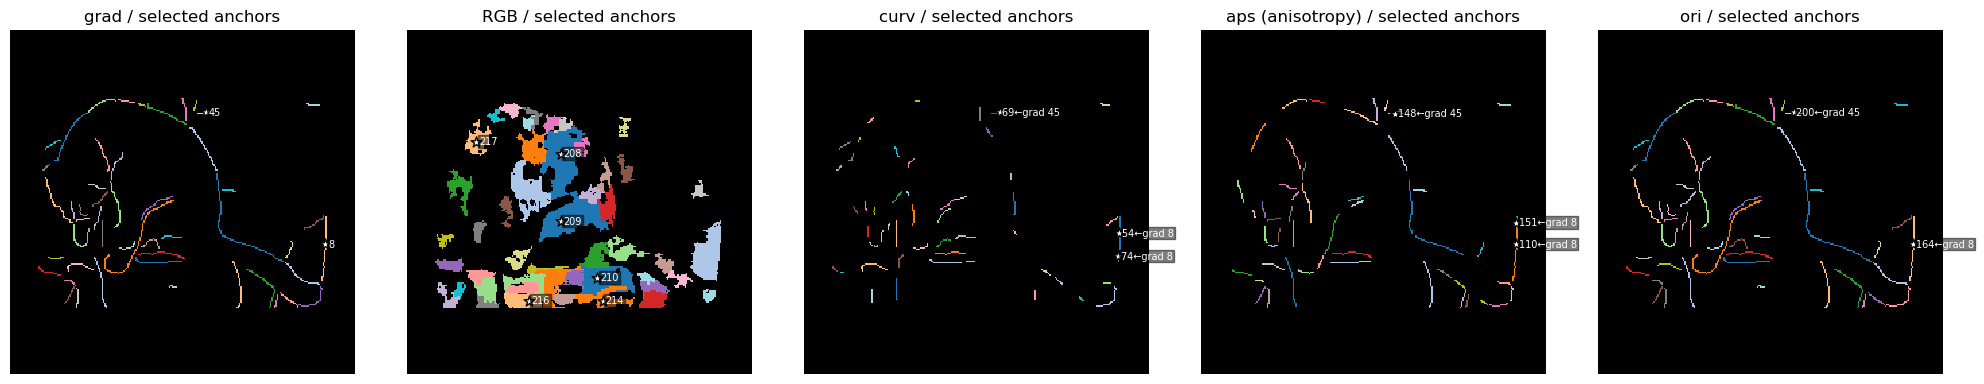

,region,modality,parent_grad,support_parent,completed,pixels,samples,selected,truncated,reason
0,0,grad,None,NaN,False,101,29,False,False,"curve_order_unresolved, sampling_target_unmet"
1,1,grad,None,NaN,False,38,13,False,False,"curve_order_unresolved, sampling_target_unmet"
2,2,grad,None,NaN,False,50,14,False,False,"curve_order_unresolved, sampling_target_unmet"
3,3,grad,None,NaN,False,35,11,False,False,"curve_order_unresolved, sampling_target_unmet"
4,4,grad,None,NaN,False,42,13,False,False,"curve_order_unresolved, sampling_target_unmet"
...,...,...,...,...,...,...,...,...,...,...
251,251,RGB,None,NaN,True,66,5,False,False,
252,252,RGB,None,NaN,True,65,4,False,False,
253,253,RGB,None,NaN,True,65,3,False,False,
254,254,RGB,None,NaN,True,64,4,False,False,


,region,foreground,geometry,sampling,completed
0,8,1.0,0.5,0.5,False
1,45,1.0,1.0,1.0,True
2,54,1.0,1.0,1.0,True
3,69,1.0,1.0,1.0,True
4,74,1.0,1.0,1.0,True
5,110,1.0,0.5,0.5,False
6,148,1.0,1.0,1.0,True
7,151,1.0,1.0,1.0,True
8,164,1.0,0.5,0.5,False
9,200,1.0,1.0,1.0,True


构图: {'build_id': 1, 'shape': (256, 256), 'regions': 256, 'sample_instances': 1481, 'referenced_nodes': 1481, 'region_containers': 256, 'contact_containers': 1024, 'edge_attribute_regions': 0, 'completed_regions': 92, 'truncated_regions': 0, 'edge_observations': 2249, 'rejected': {'nonfinite_pixels': 0, 'advanced_grad_gate_2': 12421, 'advanced_grad_gate_3': 14620, 'advanced_grad_gate_4': 13694, 'local_similarity': 59542, 'direction_conflict': 269, 'junction_connections': 94, 'region_budget': 529, 'small_region': 20402, 'refinement_attribute_discontinuity_2': 681, 'refinement_attribute_discontinuity_3': 321, 'refinement_attribute_discontinuity_4': 13, 'surface_barrier': 30346, 'region_range': 2425, 'contact_pair_budget': 1, 'contact_budget': 583}, 'timings': {'supports': 0.0721468569827266, 'regions': 0.35035610699560493, 'contacts': 0.23521973402239382, 'sampling': 0.08232892904197797, 'writing': 0.28395555599126965, 'total': 1.0243331019883044}, 'warnings': []}


,modality,own_gate_pixels,grad_eligible,writable,active,regions,samples,inherited_regions,parent_violations
0,curv,29097,19192,1354,1354,52,180,0,0
1,aps (anisotropy),33812,19192,1354,1354,52,248,0,0
2,ori,32794,19192,1353,1353,52,319,0,0


成员选择: {'selected_leaves': 136, 'rejected': {}, 'foreground_source': 'bbox_only'}


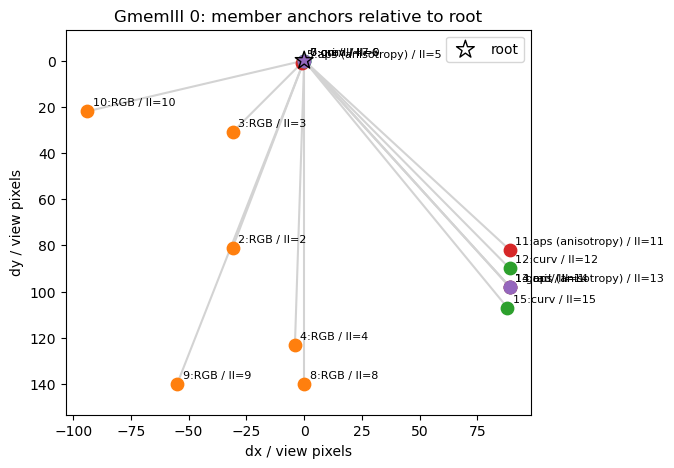

,entity,label,status,members,support,annotation_confirmed,visually_confirmed
0,0,cat,stable,16,1.0,annotation_confirmed,False


学习后原图自检（非泛化成绩） {'seconds': 0.31784422299824655, 'status': 'PREDICTED', 'class_id': 'cat', 'scores': {'cat': 0.6003439426422119, 'dog': 0.0, 'car': 0.0}, 'top_k': [('cat', 0.6003439426422119), ('dog', 0.0), ('car', 0.0)], 'entity_id': 0, 'point': (np.float64(144.42198340189498), np.float64(60.455238645202385)), 'bbox': (181.60983879627912, 59.63228608551161, 325.60983879627906, 166.63228608551157), 'search_complete': False, 'assignment_search_complete': False, 'absence_proven': False, 'graph_version': 1}
search audit: {'mode': 'sparse_translation', 'search_complete': False, 'assignment_search_complete': False, 'feature_events': 8377, 'event_budget_dropped': 32271, 'region_pose_pruned_or_dropped': 4233, 'entity_pose_pruned_or_dropped': 0, 'candidate_budget_dropped': 0, 'geometry_evaluations': 132, 'structural_fallback': False}


,entity,score,coverage,evaluable,geometry_error,point
0,0,0.826982,0.932133,1.0,1.414214,"(144.42198340189498, 60.455238645202385)"


普通检索是否找到刚写入实体: True
已知写入原点精验（仅用于定位故障）:


,template_id,level,point,score,evaluable_coverage,matched_coverage,geometry_error,accepted,matched_roles,evaluated_roles,role_bits_hex,evaluated_bits_hex,version,rejection_reasons
0,0,3,"(145.0, 61.0)",0.999997,1.0,1.0,7.944109e-15,True,136,136,0xffffffffffffffffffffffffffffffffff,0xffffffffffffffffffffffffffffffffff,1,[]


,role,template_id,level,point,score,evaluable_coverage,matched_coverage,geometry_error,accepted,matched_roles,evaluated_roles,role_bits_hex,evaluated_bits_hex,version,rejection_reasons
0,0,0,2,"(145.0, 61.0)",0.999999,1.0,1.0,2.220446e-15,True,4,4,0xf,0xf,1,[]
1,1,1,2,"(234.0, 159.0)",0.999988,1.0,1.0,3.757863e-15,True,15,15,0x7fff,0x7fff,1,[]
2,2,2,2,"(114.0, 142.0)",1.000000,1.0,1.0,7.324107e-15,True,18,18,0x3ffff,0x3ffff,1,[]
3,3,3,2,"(114.0, 92.0)",0.999999,1.0,1.0,7.944109e-15,True,18,18,0x3ffff,0x3ffff,1,[]
4,4,4,2,"(141.0, 184.0)",1.000000,1.0,1.0,7.119292e-15,True,13,13,0x1fff,0x1fff,1,[]
5,5,5,2,"(144.0, 62.0)",0.999996,1.0,1.0,1.078796e-15,True,4,4,0xf,0xf,1,[]
6,6,6,2,"(145.0, 61.0)",0.999996,1.0,1.0,2.220446e-15,True,4,4,0xf,0xf,1,[]
7,7,7,2,"(145.0, 61.0)",0.999996,1.0,1.0,2.220446e-15,True,4,4,0xf,0xf,1,[]
8,8,8,2,"(145.0, 201.0)",1.000000,1.0,1.0,3.996803e-15,True,8,8,0xff,0xff,1,[]
9,9,9,2,"(90.0, 201.0)",0.999997,1.0,1.0,3.580362e-15,True,7,7,0x7f,0x7f,1,[]


,level,template_id,candidates,accepted,best
0,2,11,8,3,"{'point': (64.0, 156.05641139648546), 'score':..."
1,2,7,8,1,"{'point': (225.01143191039077, 135.49428404480..."
2,2,0,8,6,"{'point': (225.320157803132, 203.3399210984340..."
3,2,5,8,2,"{'point': (72.02229840647516, 52.0), 'score': ..."
4,2,15,8,6,"{'point': (108.0, 51.007526601367), 'score': 0..."
5,2,6,8,2,"{'point': (230.0, 111.0), 'score': 0.693916513..."
6,2,8,8,5,"{'point': (143.79748873364434, 201.01698074325..."
7,2,4,8,3,"{'point': (141.12379665377688, 183.00111221853..."
8,2,9,8,4,"{'point': (89.34621976407131, 200.346219764071..."
9,2,14,8,0,"{'point': (68.0, 207.74026490507157), 'score':..."


重复观察: {'status': 'ALREADY_OBSERVED', 'nodes_unchanged': True, 'support_unchanged': True}


,image_id,class,status,encoder_seconds,learn_seconds,GmemI,GmemII,GmemIII,peak_rss_bytes,rss_bytes,cuda_allocated_bytes,cuda_reserved_bytes,cuda_peak_allocated_bytes
0,007530,cat,ANNOTATED_SEED_CREATED,0.003507,1.048749,136,16,1,1809817600,1792606208,12071424,58720256,45378048


In [6]:
def run_single_demo(index):
    annotation, observation = demo_inputs[index]
    print(f'开始单图 {index+1}: {annotation.image_id}', flush=True)
    sync(); started = time.perf_counter()
    features = demo_encoder(observation)
    sync(); encoded_at = time.perf_counter()
    feature_rows=[]
    for mid,value in features.items():
        finite=torch.isfinite(value); values=value[finite]
        feature_rows.append({'modality':MODALITIES[mid],'shape':tuple(value.shape),
            'finite_fraction':float(finite.float().mean()),'nan':int(torch.isnan(value).sum()),
            'inf':int(torch.isinf(value).sum()),'min':float(values.min()) if values.numel() else None,
            'max':float(values.max()) if values.numel() else None})
    display(pd.DataFrame(feature_rows))
    before = graph_counts(demo_model)
    query_debug(demo_learner, features, observation, '学习前检索（第二图时用于观察跨图响应）')
    sync(); learn_start=time.perf_counter()
    result = demo_learner.learn_object(observation,features,search_budget=search_budget,capture_debug=True,profile_stages=PROFILE_STAGES)
    sync(); learn_seconds=time.perf_counter()-learn_start
    debug=demo_learner.last_debug
    print('学习结果:', result)
    display(pd.DataFrame([{'stage':k,'seconds':v} for k,v in result.get('stage_seconds',{}).items()]))
    display(pd.DataFrame.from_dict(result.get('modality_counts',{}),orient='index').rename_axis('modality'))
    display(pd.DataFrame([{'stage':'before',**before},{'stage':'after',**graph_counts(demo_model)}]))
    show_regions(debug)
    show_entity(demo_model,result.get('entity_id'))
    display(pd.DataFrame(entity_rows(demo_model)))
    prediction=query_debug(demo_learner,features,observation,'学习后原图自检（非泛化成绩）')
    if RUN_WRITE_RECALL_AUDIT and debug and 'write_witness' in debug:
        audit=demo_learner.diagnose_write_recall(observation,features,debug['write_witness'])
        print('普通检索是否找到刚写入实体:',audit['ordinary_target_hit'])
        print('已知写入原点精验（仅用于定位故障）:')
        display(pd.DataFrame(audit['known_pose_entity']))
        display(pd.DataFrame(audit['known_pose_regions']))
        display(pd.DataFrame(audit['query']['trace']))
        OUTPUT.mkdir(parents=True,exist_ok=True)
        (OUTPUT/f'demo_{annotation.image_id}_recall.json').write_text(json.dumps(audit,ensure_ascii=False,indent=2,default=str))
    counts_before_repeat=graph_counts(demo_model)
    support_before={eid:e.evidence.support for eid,e in demo_model.gmem_iii.entity_nodes.items()}
    if result['status'] in ('MATCHED_UPDATED','ANNOTATED_SEED_CREATED','ALREADY_OBSERVED'):
        replay=demo_learner.learn_object(observation,features,search_budget=search_budget)
        print('重复观察:', {'status':replay['status'],
            'nodes_unchanged':counts_before_repeat==graph_counts(demo_model),
            'support_unchanged':support_before=={eid:e.evidence.support for eid,e in demo_model.gmem_iii.entity_nodes.items()}})
    else:
        print('本次未提交，跳过重复构图；先检查状态与分割原因。')
    row={'image_id':annotation.image_id,'class':annotation.class_id,'status':result['status'],
         'encoder_seconds':encoded_at-started,'learn_seconds':learn_seconds,
         **graph_counts(demo_model),**resource_snapshot(DEVICE)}
    demo_results.append(row)
    display(pd.DataFrame([row]))
    demo_learner.last_debug=None
    return prediction

if RUN_SINGLE_DEMOS:
    demo_prediction_1 = run_single_demo(0)
else:
    print('两张单图演示已关闭。')


## 5. 图片二：沿用第一张的记忆

第二张来自不同原图、同一类别。学习前的响应更有助于观察跨图检索，学习后重点看 MATCHED_UPDATED / ANNOTATED_SEED_CREATED / UNRESOLVED 及其原因。不同姿态允许建立新实体，不强求两张图合并。


开始单图 2: 000209


,modality,shape,finite_fraction,nan,inf,min,max
0,grad,"(1, 4, 256, 256)",1.0,0,0,-10.022427,10.025043
1,RGB,"(1, 3, 256, 256)",1.0,0,0,0.000138,0.907906
2,curv,"(1, 3, 256, 256)",1.0,0,0,0.000000,1.000000
3,aps (anisotropy),"(1, 3, 256, 256)",1.0,0,0,-1.000000,1.000000
4,ori,"(1, 6, 256, 256)",1.0,0,0,-1.570796,1.570796


学习前检索（第二图时用于观察跨图响应） {'seconds': 1.7492882119840942, 'status': 'UNRESOLVED', 'class_id': None, 'scores': {'cat': 0.0, 'dog': 0.0, 'car': 0.0}, 'top_k': [('cat', 0.0), ('dog', 0.0), ('car', 0.0)], 'entity_id': None, 'point': None, 'bbox': None, 'search_complete': False, 'assignment_search_complete': False, 'absence_proven': False, 'graph_version': 1}
search audit: {'mode': 'sparse_translation', 'search_complete': False, 'assignment_search_complete': False, 'feature_events': 8335, 'event_budget_dropped': 32129, 'region_pose_pruned_or_dropped': 4266, 'entity_pose_pruned_or_dropped': 0, 'candidate_budget_dropped': 0, 'geometry_evaluations': 941, 'structural_fallback': True}


""


学习结果: {'status': 'ANNOTATED_SEED_CREATED', 'graph_version': 2, 'seconds': 1.5551206429954618, 'stage_seconds': {'validation': 0.0008897350053302944, 'observation_build': 1.082233469991479, 'selection': 0.0038646869943477213, 'region_matching': 0.13894770003389567, 'entity_matching': 0.28735448099905625, 'pool_copy': 0.008654369972646236, 'update_and_commit': 0.03317480901023373}, 'profile_synchronized': True, 'modality_counts': {0: {'writable': 11382, 'support': 5224, 'regions': 52, 'selected': 3, 'truncated_regions': 0, 'grad_eligible': 0, 'own_gate_before_grad': 11382}, 1: {'writable': 35438, 'support': 35438, 'regions': 48, 'selected': 5, 'truncated_regions': 0, 'grad_eligible': 0, 'own_gate_before_grad': 35438}, 2: {'writable': 1630, 'support': 1630, 'regions': 52, 'selected': 7, 'truncated_regions': 0, 'grad_eligible': 19463, 'own_gate_before_grad': 33313}, 3: {'writable': 1630, 'support': 1630, 'regions': 52, 'selected': 5, 'truncated_regions': 0, 'grad_eligible': 19463, 'own_gat

,stage,seconds
0,validation,0.000890
1,observation_build,1.082233
2,selection,0.003865
3,region_matching,0.138948
4,entity_matching,0.287354
5,pool_copy,0.008654
6,update_and_commit,0.033175


,writable,support,regions,selected,truncated_regions,grad_eligible,own_gate_before_grad
modality,,,,,,,
0,11382,5224,52,3,0,0,11382
1,35438,35438,48,5,0,0,35438
2,1630,1630,52,7,0,19463,33313
3,1630,1630,52,5,0,19463,35524
4,1629,1629,52,3,0,19463,34797


,stage,GmemI,GmemII,GmemIII
0,before,136,16,1
1,after,449,39,2


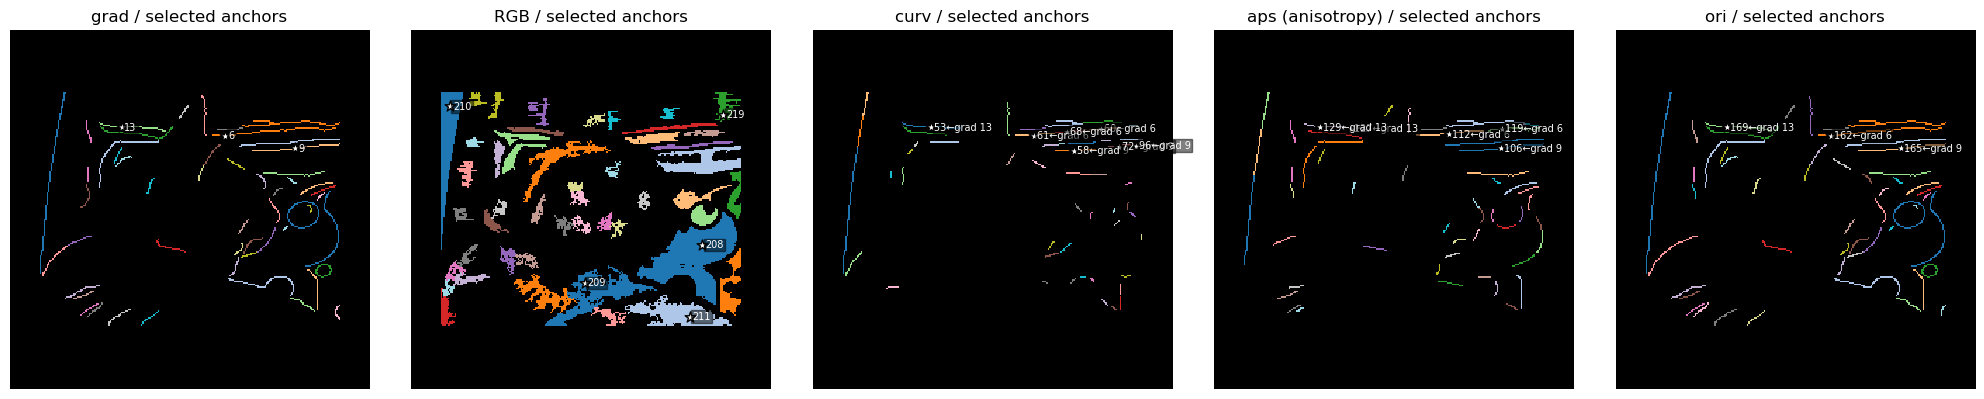

,region,modality,parent_grad,support_parent,completed,pixels,samples,selected,truncated,reason
0,0,grad,None,NaN,False,136,31,False,False,"curve_order_unresolved, sampling_target_unmet"
1,1,grad,None,NaN,False,78,25,False,False,"curve_order_unresolved, sampling_target_unmet"
2,2,grad,None,NaN,False,67,25,False,False,"curve_order_unresolved, sampling_target_unmet"
3,3,grad,None,NaN,False,66,21,False,False,"curve_order_unresolved, sampling_target_unmet"
4,4,grad,None,NaN,False,75,21,False,False,"curve_order_unresolved, sampling_target_unmet"
...,...,...,...,...,...,...,...,...,...,...
251,251,RGB,None,NaN,True,56,4,False,False,
252,252,RGB,None,NaN,True,53,3,False,False,
253,253,RGB,None,NaN,True,53,1,False,False,
254,254,RGB,None,NaN,True,53,3,False,False,


,region,foreground,geometry,sampling,completed
0,6,1.0,0.5,0.5,False
1,9,1.0,1.0,1.0,True
2,13,1.0,0.5,0.5,False
3,53,1.0,1.0,1.0,True
4,58,1.0,1.0,1.0,True
5,60,1.0,0.5,0.5,False
6,61,1.0,1.0,1.0,True
7,68,1.0,1.0,1.0,True
8,72,1.0,1.0,1.0,True
9,96,1.0,1.0,1.0,True


构图: {'build_id': 1, 'shape': (256, 256), 'regions': 256, 'sample_instances': 1742, 'referenced_nodes': 1742, 'region_containers': 256, 'contact_containers': 1024, 'edge_attribute_regions': 0, 'completed_regions': 110, 'truncated_regions': 0, 'edge_observations': 2510, 'rejected': {'nonfinite_pixels': 0, 'advanced_grad_gate_2': 14740, 'advanced_grad_gate_3': 16061, 'advanced_grad_gate_4': 15385, 'local_similarity': 69159, 'direction_conflict': 279, 'junction_connections': 363, 'region_budget': 650, 'small_region': 21603, 'refinement_attribute_discontinuity_2': 749, 'refinement_attribute_discontinuity_3': 449, 'refinement_attribute_discontinuity_4': 15, 'surface_barrier': 33325, 'region_range': 502, 'contact_pair_budget': 12, 'contact_budget': 987}, 'timings': {'supports': 0.06922827899688855, 'regions': 0.33325793099356815, 'contacts': 0.2224737840006128, 'sampling': 0.1126108419848606, 'writing': 0.34384972997941077, 'total': 1.081724991032388}, 'warnings': []}


,modality,own_gate_pixels,grad_eligible,writable,active,regions,samples,inherited_regions,parent_violations
0,curv,33313,19463,1630,1630,52,237,0,0
1,aps (anisotropy),35524,19463,1630,1630,52,276,0,0
2,ori,34797,19463,1629,1629,52,345,0,0


成员选择: {'selected_leaves': 313, 'rejected': {19: 'selection_budget', 65: 'selection_budget', 138: 'selection_budget', 177: 'selection_budget'}, 'foreground_source': 'bbox_only'}


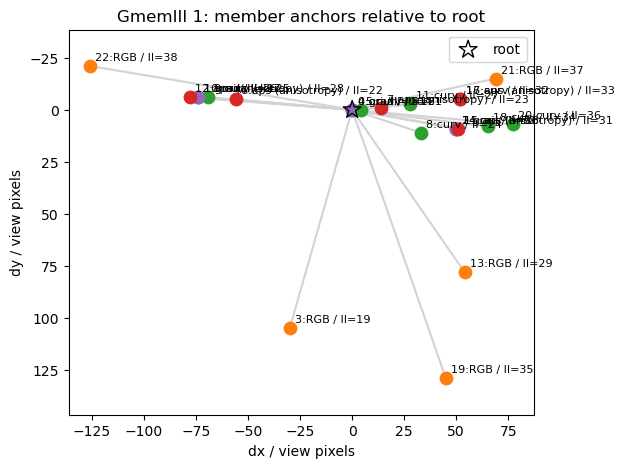

,entity,label,status,members,support,annotation_confirmed,visually_confirmed
0,0,cat,stable,16,1.0,annotation_confirmed,False
1,1,cat,stable,23,1.0,annotation_confirmed,False


学习后原图自检（非泛化成绩） {'seconds': 3.1021542769740336, 'status': 'PREDICTED', 'class_id': 'cat', 'scores': {'cat': 0.9999982714653015, 'dog': 0.0, 'car': 0.0}, 'top_k': [('cat', 0.9999982714653015), ('dog', 0.0), ('car', 0.0)], 'entity_id': 1, 'point': (np.float64(152.99999999999997), np.float64(74.99999999999999)), 'bbox': (12.999999999999957, 74.99999999999999, 400.0, 375.0), 'search_complete': False, 'assignment_search_complete': False, 'absence_proven': False, 'graph_version': 2}
search audit: {'mode': 'sparse_translation', 'search_complete': False, 'assignment_search_complete': False, 'feature_events': 27991, 'event_budget_dropped': 98357, 'region_pose_pruned_or_dropped': 9100, 'entity_pose_pruned_or_dropped': 0, 'candidate_budget_dropped': 184, 'geometry_evaluations': 2123, 'structural_fallback': True}


,entity,score,coverage,evaluable,geometry_error,point
0,1,0.999998,1.0,1.0,2.162856e-14,"(152.99999999999997, 74.99999999999999)"


普通检索是否找到刚写入实体: True
已知写入原点精验（仅用于定位故障）:


,template_id,level,point,score,evaluable_coverage,matched_coverage,geometry_error,accepted,matched_roles,evaluated_roles,role_bits_hex,evaluated_bits_hex,version,rejection_reasons
0,1,3,"(153.0, 75.0)",0.999998,1.0,1.0,1.517720e-14,True,313,313,0x1fffffffffffffffffffffffffffffffffffffffffff...,0x1fffffffffffffffffffffffffffffffffffffffffff...,1,[]


,role,template_id,level,point,score,evaluable_coverage,matched_coverage,geometry_error,accepted,matched_roles,evaluated_roles,role_bits_hex,evaluated_bits_hex,version,rejection_reasons
0,0,16,2,"(153.0, 75.0)",1.000000,1.0,1.0,1.423858e-14,True,30,30,0x3fffffff,0x3fffffff,1,[]
1,1,17,2,"(79.0, 69.0)",0.999999,1.0,1.0,7.160723e-15,True,14,14,0x3fff,0x3fff,1,[]
2,2,18,2,"(203.0, 84.0)",0.999999,1.0,1.0,7.119292e-15,True,20,20,0xfffff,0xfffff,1,[]
3,3,19,2,"(123.0, 180.0)",0.999998,1.0,1.0,7.108896e-15,True,31,31,0x7fffffff,0x7fffffff,1,[]
4,4,20,2,"(153.0, 75.0)",0.999999,1.0,1.0,1.423858e-14,True,18,18,0x3ffff,0x3ffff,1,[]
5,5,21,2,"(157.0, 75.0)",1.000000,1.0,1.0,2.028618e-15,True,8,8,0xff,0xff,1,[]
6,6,22,2,"(97.0, 70.0)",1.000000,1.0,1.0,1.897150e-15,True,6,6,0x3f,0x3f,1,[]
7,7,23,2,"(167.0, 74.0)",1.000000,1.0,1.0,4.076197e-15,True,11,11,0x7ff,0x7ff,1,[]
8,8,24,2,"(186.0, 86.0)",1.000000,1.0,1.0,3.944782e-15,True,8,8,0xff,0xff,1,[]
9,9,25,2,"(84.0, 69.0)",0.999999,1.0,1.0,4.884981e-15,True,12,12,0xfff,0xfff,1,[]


,level,template_id,candidates,accepted,best
0,2,15,56,8,"{'point': (96.0, 116.70670926659447), 'score':..."
1,2,5,56,17,"{'point': (156.0, 71.0), 'score': 0.8857441820..."
2,2,7,56,17,"{'point': (203.0, 84.0), 'score': 0.9072005688..."
3,2,6,56,6,"{'point': (230.0, 82.0), 'score': 0.8072714398..."
4,2,36,56,4,"{'point': (230.0, 82.0), 'score': 0.9999978032..."
5,2,28,55,9,"{'point': (75.0, 69.0), 'score': 1.0, 'evaluab..."
6,2,11,56,6,"{'point': (219.0, 131.0), 'score': 0.906774312..."
7,2,33,56,5,"{'point': (205.0, 70.0), 'score': 0.9999985033..."
8,2,22,55,5,"{'point': (97.0, 70.0), 'score': 0.99999975096..."
9,2,0,56,33,"{'point': (178.0, 67.0), 'score': 0.9797800536..."


重复观察: {'status': 'ALREADY_OBSERVED', 'nodes_unchanged': True, 'support_unchanged': True}


,image_id,class,status,encoder_seconds,learn_seconds,GmemI,GmemII,GmemIII,peak_rss_bytes,rss_bytes,cuda_allocated_bytes,cuda_reserved_bytes,cuda_peak_allocated_bytes
0,000209,cat,ANNOTATED_SEED_CREATED,0.003361,1.557763,449,39,2,1818808320,1807646720,12391936,75497472,65785856


,image_id,class,status,encoder_seconds,learn_seconds,GmemI,GmemII,GmemIII,peak_rss_bytes,rss_bytes,cuda_allocated_bytes,cuda_reserved_bytes,cuda_peak_allocated_bytes
0,007530,cat,ANNOTATED_SEED_CREATED,0.003507,1.048749,136,16,1,1809817600,1792606208,12071424,58720256,45378048
1,000209,cat,ANNOTATED_SEED_CREATED,0.003361,1.557763,449,39,2,1818808320,1807646720,12391936,75497472,65785856


In [7]:
if RUN_SINGLE_DEMOS:
    demo_prediction_2 = run_single_demo(1)
    display(pd.DataFrame(demo_results))
else:
    print('第二张单图演示已关闭。')


## 6. 批量建图：独立记忆、逐目标日志与中断保存

完整数据划分不再随处理上限变化。`BATCH_START_IMAGE` 指定原图游标，处理上限仅控制本次执行范围。先设置 `RUN_MEMORY_BUILD=True`，默认试跑 20 张原图中全部选定类别目标；`BATCH_IMAGE_LIMIT=None` 扩展到完整建图划分。这里的“批量”是数据集顺序循环，不是并行图写入。单步搜索预算仍默认关闭。

演示记忆会释放，批量模型从空图开始，或从 `RESUME_CHECKPOINT` 恢复。每个目标即时输出状态/原因、节点数量、独立支持、用时及内存；定期和正常结束/手动中断时保存 checkpoint。重跑本节会继续使用当前批量 learner，由 ledger 去重；改变划分或配置应重新初始化。


In [8]:
def serializable(value):
    if isinstance(value,np.generic): return value.item()
    if isinstance(value,np.ndarray): return value.tolist()
    raise TypeError(type(value).__name__)

batch_rows=globals().get('batch_rows',[])
if RUN_MEMORY_BUILD:
    batch_manifest=copy.deepcopy(split_manifest)
    if 'learner' not in globals():
        # 删除演示图及编码器以免并存显存；重新演示需从第 3 节初始化。
        del demo_learner, demo_model, demo_encoder
        gc.collect()
        if DEVICE.type=='cuda': torch.cuda.empty_cache()
        memory_config,encoder,model,learner=new_system()
        if RESUME_CHECKPOINT:
            learner.load(RESUME_CHECKPOINT)
    experiment=SupervisedExperiment(learner,encoder,dataset,batch_manifest)
    OUTPUT.mkdir(parents=True,exist_ok=True)
    (OUTPUT/'split.json').write_text(json.dumps(batch_manifest,ensure_ascii=False,indent=2))
    print('完整建图集:',len(batch_manifest['splits']['memory_build']),
          '本次原图数:',len(experiment.image_window('memory_build',BATCH_IMAGE_LIMIT,BATCH_START_IMAGE)),
          '起点:',BATCH_START_IMAGE,'日志:',OUTPUT,flush=True)
    def record_result(result):
        counts=graph_counts(learner.model)
        row={k:result.get(k) for k in ('image_id','object_id','class_id','status','reason',
            'entity_id','independent_support','encoder_seconds','total_seconds')}
        row['stage_seconds']=result.get('stage_seconds',{})
        row['work_counts']=result.get('work_counts',{})
        row['modality_counts']=result.get('modality_counts',{})
        row.update(counts)
        row.update(result['resources'])
        batch_rows.append(row)
        with (OUTPUT/'learning.jsonl').open('a') as stream:
            stream.write(json.dumps(row,ensure_ascii=False,default=serializable)+'\n')
        print(row,flush=True)
        if CHECKPOINT_EVERY and len(batch_rows)%CHECKPOINT_EVERY==0:
            learner.save(OUTPUT/'memory.pt')
    try:
        batch_result=experiment.build_memory(search_budget=search_budget,on_result=record_result,
            max_images=BATCH_IMAGE_LIMIT,start_image=BATCH_START_IMAGE,profile_stages=PROFILE_STAGES)
        print(batch_result['status_counts'])
    except KeyboardInterrupt:
        print('已手动中断；保存最后完整提交的图，未完成的目标可重试。')
    finally:
        learner.save(OUTPUT/'memory.pt')
    display(pd.DataFrame(entity_rows(learner.model)))
    print('memory invariants:', audit_memory(learner))
else:
    print('批量训练未启动：完成两图演示后设置 RUN_MEMORY_BUILD=True，再执行本节。')


批量训练未启动：完成两图演示后设置 RUN_MEMORY_BUILD=True，再执行本节。


## 7. 批量运行统计

单个点代表一个标注目标，不是一张原图。RSS 为整个内核进程占用，CUDA reserved 包含缓存；峰值是进程/设备已有统计口径，不等于图本身大小。ALREADY_OBSERVED 不算新增学习成功。


In [9]:
if batch_rows:
    table=pd.DataFrame(batch_rows)
    display(table)
    display(table.groupby('status').size().rename('objects').to_frame())
    display(pd.DataFrame(list(table['stage_seconds'])).fillna(0).agg(['sum','mean','max']).T)
    display(table.groupby(['status','reason'],dropna=False).size().rename('objects').to_frame())
    fig,axes=plt.subplots(1,3,figsize=(16,4))
    axes[0].plot(table['total_seconds'].to_numpy(),label='per-object total')
    axes[0].set_ylabel('seconds'); axes[0].legend()
    for name in ('GmemI','GmemII','GmemIII'):
        axes[1].plot(table[name].to_numpy(),label=name)
    axes[1].set_ylabel('nodes'); axes[1].legend()
    for name in ('rss_bytes','cuda_allocated_bytes','cuda_reserved_bytes'):
        if name in table:
            axes[2].plot(table[name].to_numpy()/2**20,label=name)
    axes[2].set_ylabel('MiB'); axes[2].legend()
    for ax in axes: ax.set_xlabel('processed annotation index')
    plt.tight_layout(); plt.show()
else:
    print('暂无批量记录。')


暂无批量记录。


## 8. 留出查询与可选分类头

所有留出集只查询不写图。小批量中类别缺失时分类头可能拒绝拟合，应扩大样本范围；不要复制训练图片补足留出集。test 未解压时只报告 validation。单图自检结果不参与此处统计。


In [10]:
caches={}
if RUN_QUERY:
    if 'experiment' not in globals():
        raise RuntimeError('先完成批量初始化/建图。')
    if not learner.ledger:
        raise RuntimeError('尚无成功提交的监督实体，请先查看学习失败原因。')
    for split in ('readout_fit','validation','test'):
        if not experiment.splits['splits'][split]:
            print(split,'为空，跳过'); continue
        caches[split]=experiment.query_split(split,exact=False,max_images=QUERY_IMAGE_LIMIT)
        if split!='readout_fit': print(split,experiment.evaluate(caches[split]))
        print(split,caches[split]['resources'])
trainer=None
if RUN_HEAD_FIT:
    if not all(k in caches for k in ('readout_fit','validation')):
        raise RuntimeError('先打开 RUN_QUERY 并生成 readout_fit/validation 缓存。')
    trainer=ClassifierTrainer(classes,learner.graph_version,config,device=DEVICE)
    print(trainer.fit(caches['readout_fit'],caches['validation'],experiment.splits['splits']['memory_build']))
    print('validation:',experiment.evaluate(caches['validation'],trainer))
    if 'test' in caches: print('test:',experiment.evaluate(caches['test'],trainer))
    learner.save(OUTPUT/'memory_and_head.pt',trainer)


## 9. 可选无框检测

只给整图生成候选和预测，真值仅用于事后评价。优先使用官方 test，未解压时明确使用 validation。此处单图和过滤 difficult 后的简化 AP 均不能称为 VOC 官方测试 mAP。


In [11]:
if RUN_DETECTION:
    if 'learner' not in globals() or not learner.ledger:
        raise RuntimeError('请先完成批量监督建图。')
    split='test' if experiment.splits['splits']['test'] else 'validation'
    image_id=experiment.splits['splits'][split][0]
    image,objects=dataset.load_image_objects(image_id)
    prediction=ProposalDetector(learner,encoder).detect(image,image_id=image_id)
    print('evaluation split:',split)
    print({k:v for k,v in prediction.items() if k not in ('proposals','detections')})
    display(pd.DataFrame(prediction['detections']))
    print(detection_metrics(prediction['detections'],{image_id:objects},classes,
        iou_threshold=.5,proposals={image_id:prediction['proposals']}))
